In [1]:
# Load the Dataset into python
import pandas as pd

df=pd.read_excel("C:/Data Science/Assignments_Files/Clustering/EastWestAirlines.xlsx",sheet_name="data")
df.head()


,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
# 1.Remove Unnecessary Columns
df.drop(columns=["ID#"],inplace=True)

In [5]:
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [7]:
# 2.Remove Outliers if found 

import numpy as np
Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1

df=df[-((df<(Q1-1.5*IQR)) |
        (df>(Q3+1.5*IQR))).any(axis=1)]

In [9]:
df=df.copy()
df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
5,16420,0,1,1,1,0,0,0,0,6942,0


In [11]:
# 3.Scaling features

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
scaled_data=scaler.fit_transform(df)

In [19]:
df.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2875.000000,2875.0,2875.000000,2875.0,2875.0,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000,2875.000000
mean,46840.297739,0.0,1.829913,1.0,1.0,10872.930435,9.385739,57.085217,0.198609,3926.959652,0.279652
std,42611.722286,0.0,1.154373,0.0,0.0,13664.119401,7.753492,150.711569,0.484841,2044.017792,0.448906
min,50.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,8.000000,0.000000
25%,15275.000000,0.0,1.000000,1.0,1.0,500.000000,2.000000,0.000000,0.000000,2154.500000,0.000000
50%,33327.000000,0.0,1.000000,1.0,1.0,4500.000000,9.000000,0.000000,0.000000,3805.000000,0.000000
75%,65980.500000,0.0,3.000000,1.0,1.0,17089.000000,15.000000,0.000000,0.000000,5566.000000,1.000000
max,202636.000000,0.0,5.000000,1.0,1.0,57382.000000,38.000000,767.000000,2.000000,8296.000000,1.000000


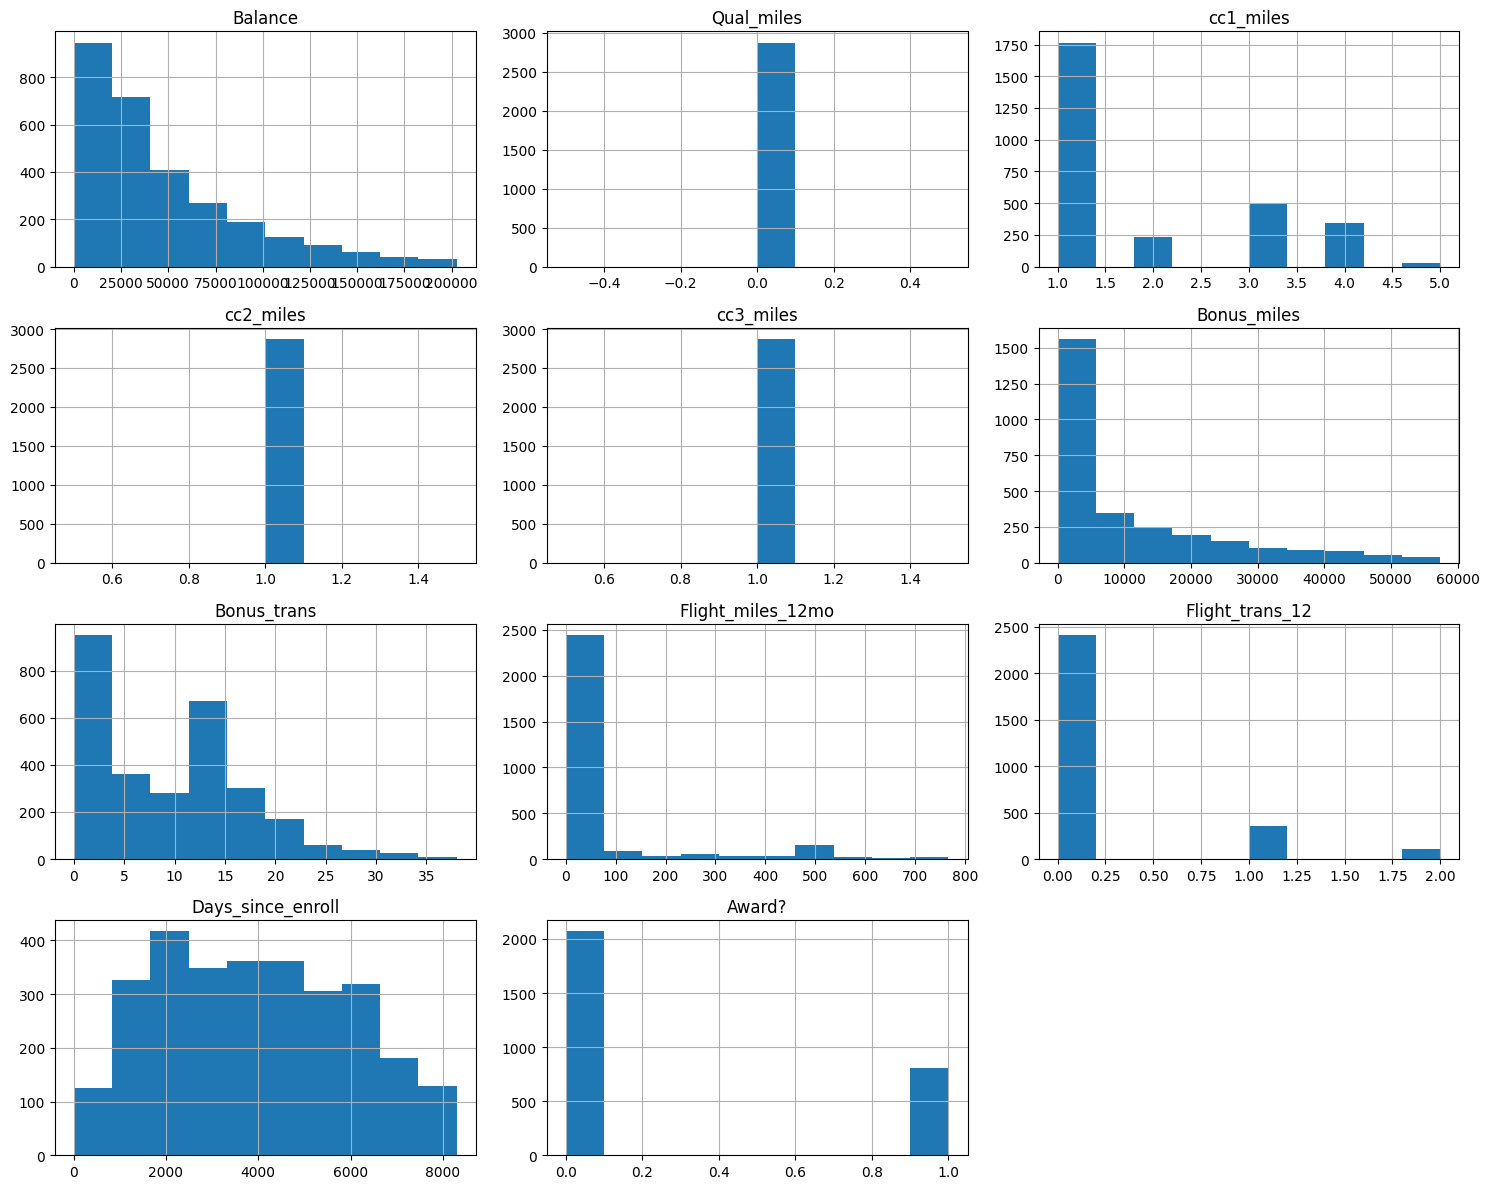

In [21]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

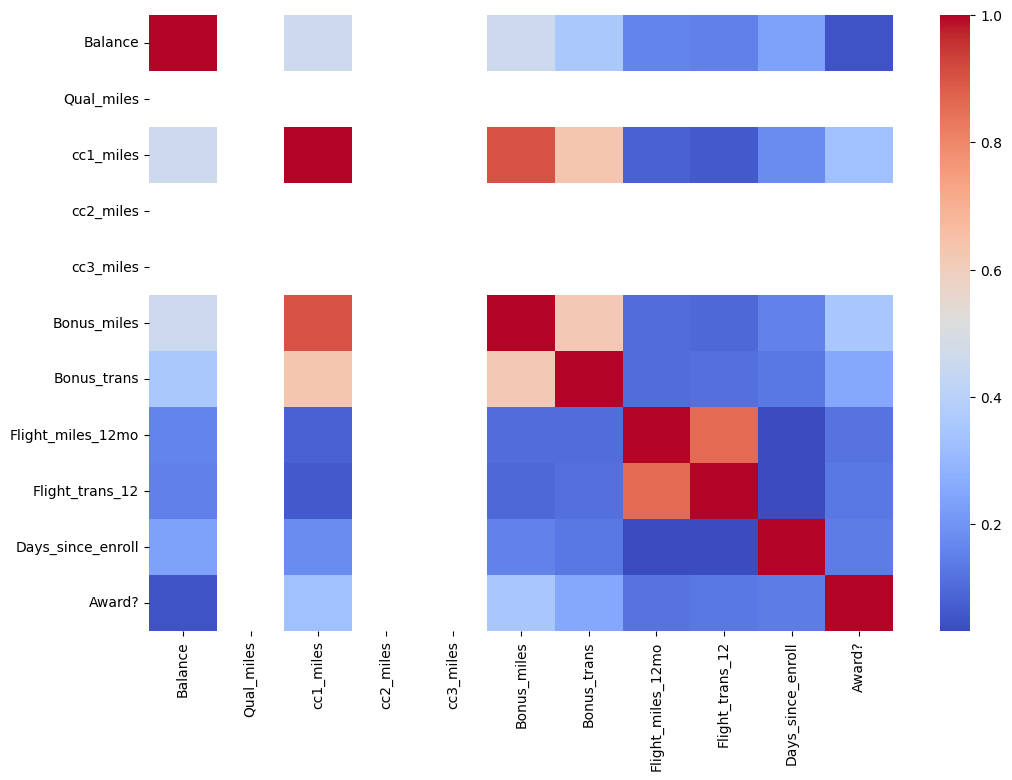

In [23]:
# Correlation Analysis
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm",annot=False)
plt.show()

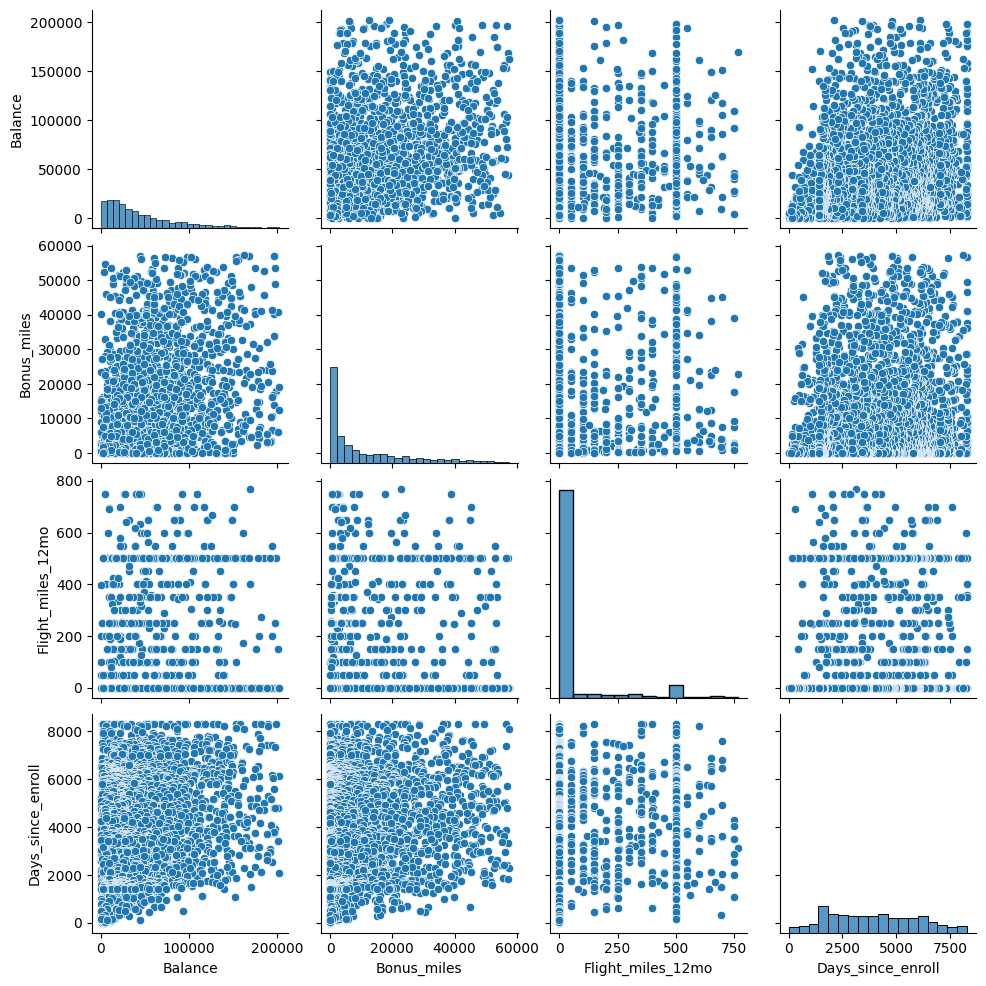

In [25]:
# Visualizations for Hidden Patterns
# 1.Pairplot (Customer Behavior)

sns.pairplot(df[['Balance', 'Bonus_miles', 'Flight_miles_12mo', 'Days_since_enroll']])
plt.show()

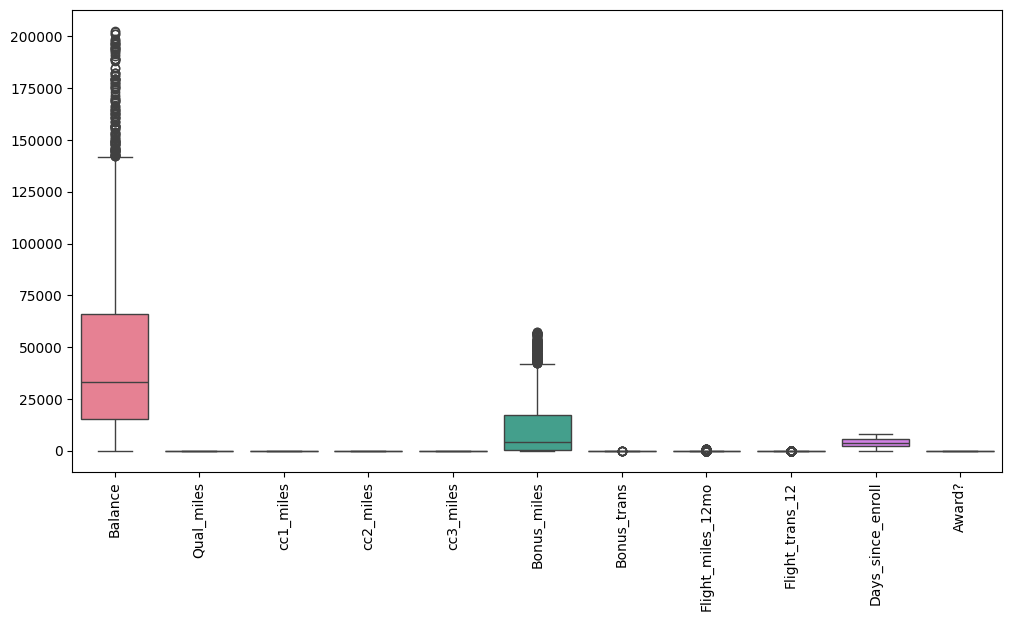

In [27]:
# 2.Boxplots (Outlier Visualization)

plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

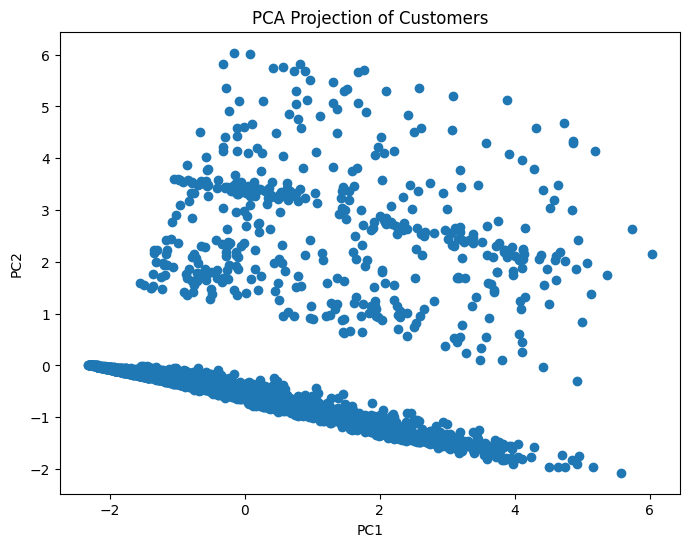

In [29]:
# 3.PCA for Cluster Visualization

from sklearn.decomposition import PCA
pca=PCA(n_components=2)
pca_data =pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0],pca_data[:,1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of Customers")
plt.show()

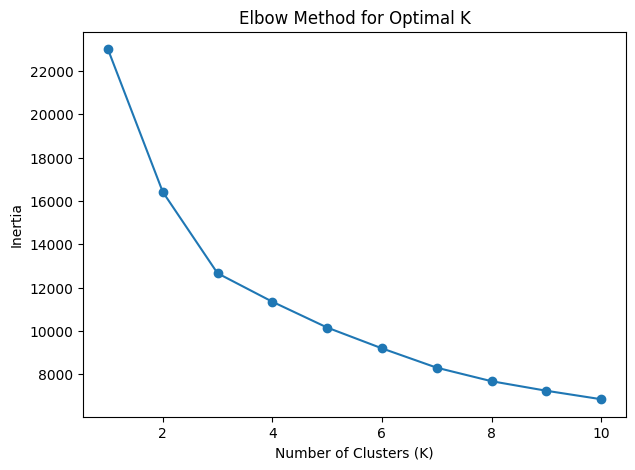

In [31]:
# 1. K-Means Clustering 

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]

K=range(1,11)

for k in K:
    kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K,inertia,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [33]:
#Applying K-Means
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(scaled_data)

df["KMeans_Cluster"]=kmeans_labels
df["KMeans_Cluster"].value_counts()

KMeans_Cluster
0    1543
3     539
1     453
2     340
Name: count, dtype: int64

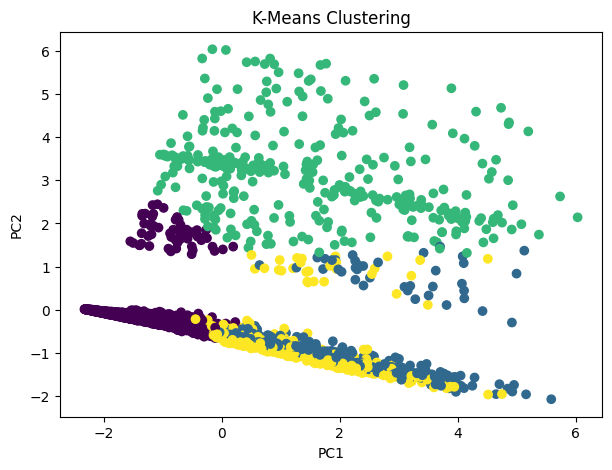

In [35]:
#Visualization (PCA)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_data)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clustering")
plt.show()

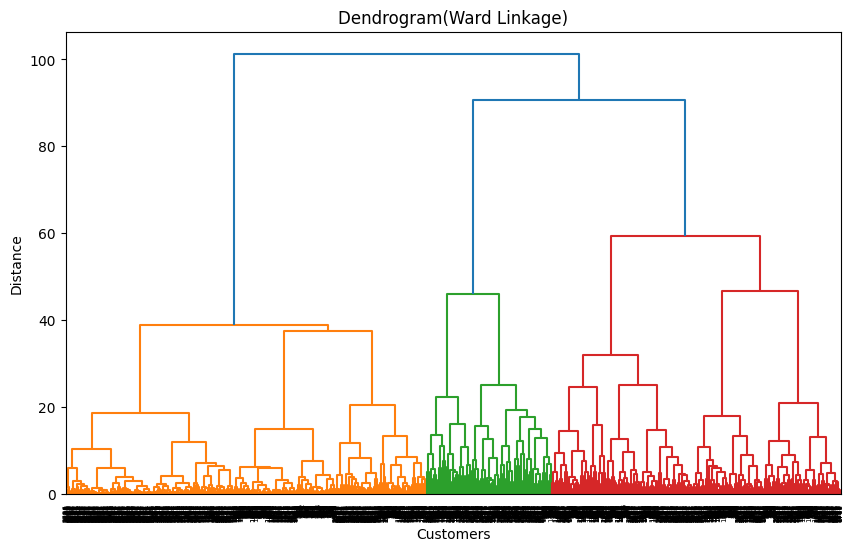

In [37]:
# 2. Hierarchical Clustering
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,6))
sch.dendrogram(sch.linkage(scaled_data,method='ward'))
plt.title("Dendrogram(Ward Linkage)")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [39]:
# Apply Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

hc=AgglomerativeClustering(n_clusters=4,linkage="ward")
hc_labels=hc.fit_predict(scaled_data)
df.loc[:,"Hierarchical_Cluster"]=hc_labels

In [41]:
#Experimenting with Linkage Criteria

for method in ["ward","complete","average","single"]:
    hc=AgglomerativeClustering(n_clusters=4,linkage=method)
    labels=hc.fit_predict(scaled_data)
    print(method,"clusters:",len(set(labels)))

ward clusters: 4
complete clusters: 4
average clusters: 4
single clusters: 4


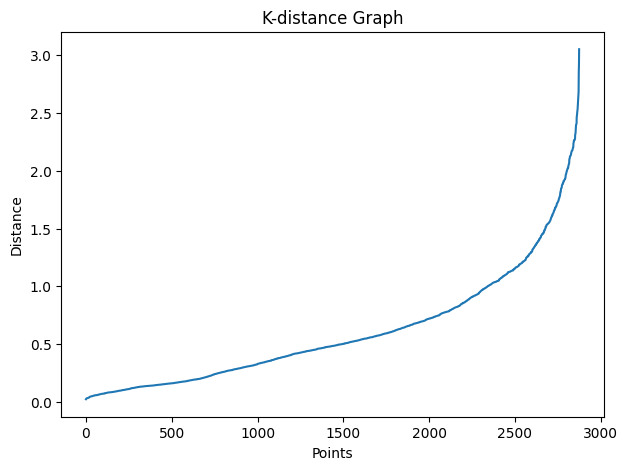

In [43]:
# 3 DBSCAN Clustering
#Parameter Selection (epsilon & minPts)

from sklearn.neighbors import NearestNeighbors
import numpy as np

neighbors=NearestNeighbors(n_neighbors=5)
neighbors_fit=neighbors.fit(scaled_data)
distances,indices=neighbors_fit.kneighbors(scaled_data)

distances=np.sort(distances[:,4])

plt.figure(figsize=(7,5))
plt.plot(distances)
plt.xlabel("Points")
plt.ylabel("Distance")
plt.title("K-distance Graph")
plt.show()

In [45]:
# Apply DBSCAN
from sklearn.cluster import DBSCAN

dbscan=DBSCAN(eps=1.3,min_samples=5)
dbscan_labels=dbscan.fit_predict(scaled_data)

df.loc[:,"DBSCAN_Cluster"]=dbscan_labels
df["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    1799
 2     597
-1     179
 3     159
 1     109
 5      25
 4       7
Name: count, dtype: int64

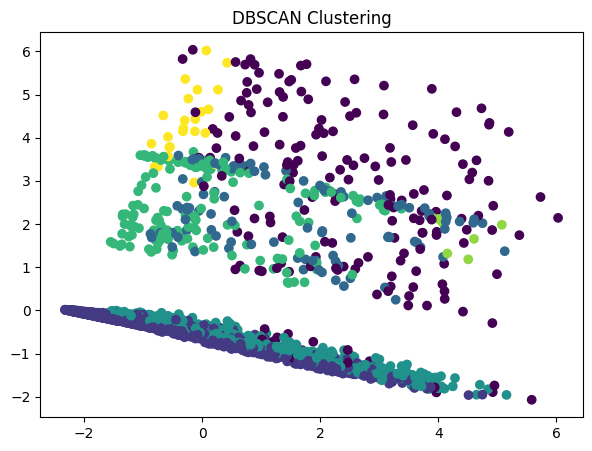

In [47]:
#DBSCAN Visualization
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0],X_pca[:,1],c=dbscan_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [49]:
# 1.K-means Clustering

kmeans_profile=df.groupby("KMeans_Cluster").mean().round(2)
kmeans_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,Hierarchical_Cluster,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,,,,
0,26357.59,0.0,1.04,1.0,1.0,2289.06,4.77,4.45,0.04,3527.23,0.13,0.95,0.34
1,53761.52,0.0,3.13,1.0,1.0,25830.54,16.00,12.15,0.08,4594.49,1.00,0.53,1.77
2,64862.87,0.0,2.00,1.0,1.0,13874.03,11.42,436.76,1.32,4123.50,0.44,2.00,1.16
3,88290.83,0.0,2.88,1.0,1.0,20981.91,15.75,6.03,0.05,4386.27,0.01,2.70,0.06


In [51]:
# 2.Hierarchical Clustering

hier_profile=df.groupby("Hierarchical_Cluster").mean().round(2)
hier_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,DBSCAN_Cluster
Hierarchical_Cluster,,,,,,,,,,,,,
0,36238.27,0.0,2.39,1.0,1.0,17373.10,12.04,0.00,0.00,4286.65,1.00,0.66,1.99
1,25586.35,0.0,1.08,1.0,1.0,2450.00,5.55,0.00,0.00,3475.01,0.00,0.15,0.00
2,61753.47,0.0,2.04,1.0,1.0,14252.57,11.41,355.90,1.24,4107.40,0.43,1.73,1.25
3,98861.71,0.0,2.96,1.0,1.0,22614.96,14.64,0.09,0.00,4546.50,0.12,2.63,0.17


In [53]:
# 3.DBSCAN Clustering

dbscan_profile=(
    df[df["DBSCAN_Cluster"]!=-1]
    .groupby("DBSCAN_Cluster")
    .mean()
    .round(2)
)
dbscan_profile

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster,Hierarchical_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,
0,42492.84,0.0,1.56,1.0,1.0,7386.67,7.83,0.00,0.0,3719.85,0.0,0.83,1.51
1,39688.19,0.0,2.30,1.0,1.0,17025.82,11.27,347.41,1.0,4051.33,1.0,1.67,2.00
2,45690.50,0.0,2.44,1.0,1.0,18190.56,12.15,0.00,0.0,4384.01,1.0,0.70,0.27
3,52469.65,0.0,1.50,1.0,1.0,6813.42,8.09,313.75,1.0,3721.87,0.0,1.50,2.00
4,110792.57,0.0,4.29,1.0,1.0,48002.57,18.71,457.14,1.0,5888.29,0.0,2.14,2.00
5,31612.28,0.0,1.00,1.0,1.0,1631.52,3.68,369.28,2.0,3309.84,0.0,2.00,2.00


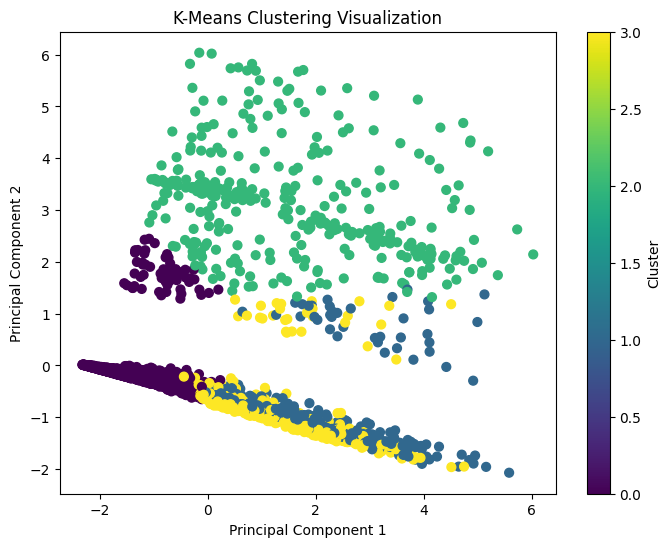

In [55]:
# 1.K-means Cluster Visualization

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["KMeans_Cluster"],
    cmap="viridis",
    s=40
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Visualization")
plt.colorbar(label="Cluster")
plt.show()

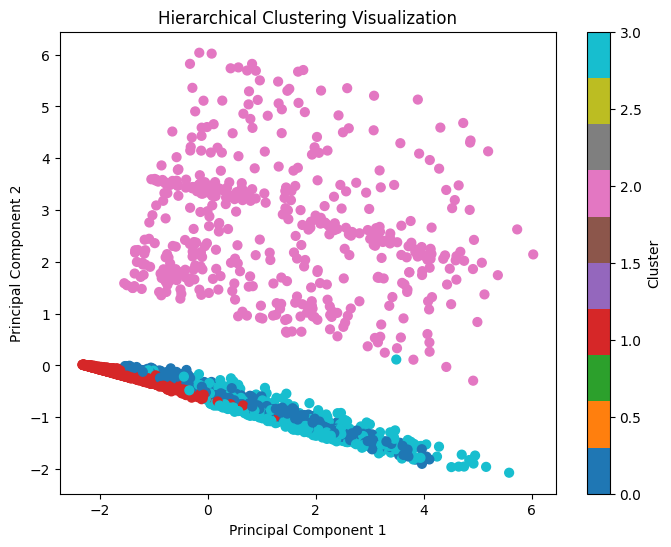

In [57]:
# 2.Hierarchical Cluster Visualization

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["Hierarchical_Cluster"],
    cmap="tab10",
    s=40
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Hierarchical Clustering Visualization")
plt.colorbar(label="Cluster")
plt.show()

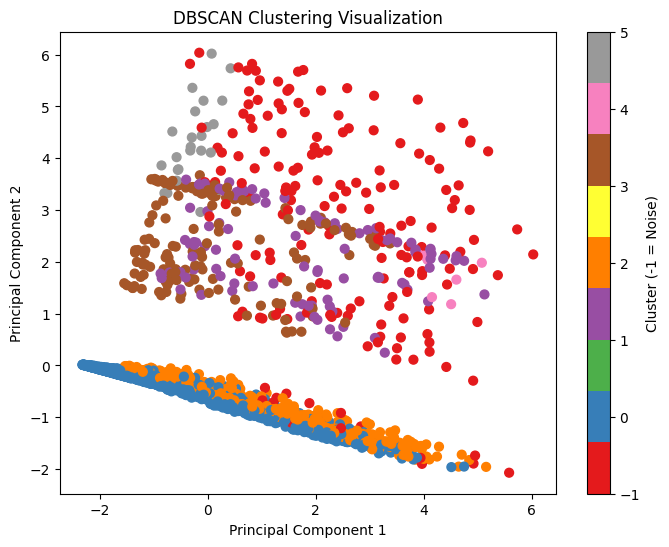

In [59]:
# 3.DBSCAN Cluster Visualization

plt.figure(figsize=(8, 6))
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df["DBSCAN_Cluster"],
    cmap="Set1",
    s=40
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DBSCAN Clustering Visualization")
plt.colorbar(label="Cluster (-1 = Noise)")
plt.show()

In [77]:
# Evaluating the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.

from sklearn.metrics import silhouette_score
import numpy as np

KMeans_Silhouette=silhouette_score(scaled_data,kmeans_labels)
Hierarchical_Silhouette=silhouette_score(scaled_data,hc_labels)

mask = dbscan_labels != -1
DBSCAN_Silhouette= silhouette_score(scaled_data[mask], dbscan_labels[mask])

In [83]:
print("KMeans Silhouette:",round(KMeans_Silhouette,3))
print("Hierarchical Silhouette:", round(Hierarchical_Silhouette,3))
print("DBSCAN Silhouette:", round(DBSCAN_Silhouette,3))

KMeans Silhouette: 0.321
Hierarchical Silhouette: 0.302
DBSCAN Silhouette: 0.274
